In [1]:
import pandas as pd

df = pd.read_csv('D:/code/gr1/clean_data/unraveled/unraveled.csv')

In [2]:
df['Stage'].value_counts()

Stage
1    3000
2    3000
0    1000
3    1000
4     359
Name: count, dtype: int64

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

X = df.drop('Stage', axis=1)
y = df['Stage']
x_train, x_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [4]:
train_index = x_train.columns
train_index

Index(['bidirectional_duration_ms', 'src2dst_packets', 'dst2src_packets',
       'src2dst_bytes', 'dst2src_bytes', 'bidirectional_mean_piat_ms',
       'bidirectional_stddev_piat_ms', 'bidirectional_max_piat_ms',
       'bidirectional_min_piat_ms', 'src2dst_mean_piat_ms',
       'src2dst_stddev_piat_ms', 'src2dst_max_piat_ms', 'src2dst_min_piat_ms',
       'dst2src_mean_piat_ms', 'dst2src_stddev_piat_ms', 'dst2src_max_piat_ms',
       'dst2src_min_piat_ms', 'bidirectional_fin_packets',
       'bidirectional_syn_packets', 'bidirectional_rst_packets',
       'bidirectional_psh_packets', 'bidirectional_ack_packets',
       'bidirectional_urg_packets', 'bidirectional_cwr_packets',
       'bidirectional_ece_packets'],
      dtype='object')

In [5]:
from sklearn.feature_selection import mutual_info_classif
mutual_info = mutual_info_classif(x_train, y_train)
mutual_info = pd.Series(mutual_info)
mutual_info.index = train_index
mutual_info.sort_values(ascending=False)

bidirectional_max_piat_ms       1.085099
dst2src_max_piat_ms             1.083739
src2dst_max_piat_ms             1.083575
dst2src_bytes                   1.072033
src2dst_stddev_piat_ms          1.035209
bidirectional_stddev_piat_ms    1.031517
src2dst_bytes                   1.026102
bidirectional_mean_piat_ms      1.020062
src2dst_mean_piat_ms            1.014373
dst2src_stddev_piat_ms          0.928700
src2dst_packets                 0.925686
bidirectional_ack_packets       0.906512
dst2src_mean_piat_ms            0.900154
bidirectional_duration_ms       0.878591
dst2src_packets                 0.845414
bidirectional_psh_packets       0.822985
bidirectional_rst_packets       0.633670
bidirectional_fin_packets       0.174985
src2dst_min_piat_ms             0.054807
dst2src_min_piat_ms             0.052919
bidirectional_syn_packets       0.028951
bidirectional_min_piat_ms       0.018077
bidirectional_urg_packets       0.009474
bidirectional_cwr_packets       0.000305
bidirectional_ec

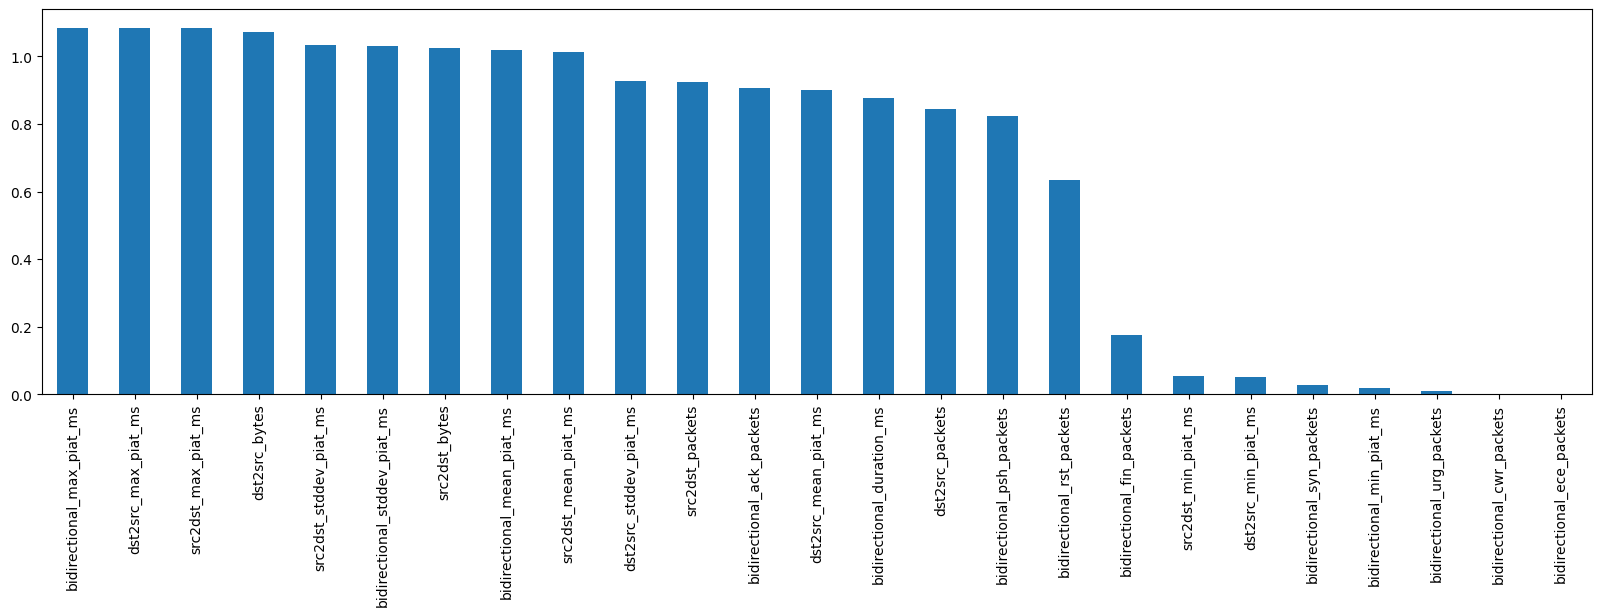

In [6]:
mutual_info.sort_values(ascending=False).plot.bar(figsize=(20, 5));


In [4]:
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
xgb_apt2021 = xgb.XGBClassifier(random_state = 42)

In [5]:
xgb_apt2021.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, objective='multi:softprob', ...)

In [9]:
y_pred = xgb_apt2021.predict(x_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)


conf_matrix = confusion_matrix(y_test, y_pred)
print(conf_matrix)

print(classification_report(y_test, y_pred))

0.9288277511961722
[[198   0   1   0   1]
 [  0 599   0   0   1]
 [  0   1 557  40   2]
 [  0   0  49 144   7]
 [  0   2   0  15  55]]
              precision    recall  f1-score   support

           0       1.00      0.99      0.99       200
           1       1.00      1.00      1.00       600
           2       0.92      0.93      0.92       600
           3       0.72      0.72      0.72       200
           4       0.83      0.76      0.80        72

    accuracy                           0.93      1672
   macro avg       0.89      0.88      0.89      1672
weighted avg       0.93      0.93      0.93      1672


In [22]:
import joblib

# Lưu mô hình vào file
joblib.dump(xgb_apt2021, "D:/code/python/code/ScoreFactor/modelv3/xgb_apt2021.pkl")

print("✅ Mô hình đã được lưu thành công!")

✅ Mô hình đã được lưu thành công!


In [23]:
xgb_apt2021_loaded = joblib.load("D:/code/python/code/ScoreFactor/modelv3/xgb_apt2021.pkl")


In [24]:
df_scivic = pd.read_csv('D:/code/gr1/clean_data/scvic/scivic_train.csv')


In [25]:
a_test = df_scivic.drop('Stage', axis=1)
b_test = df_scivic['Stage']

In [30]:
print(b_test.isnull().sum())  # Kiểm tra số lượng giá trị NaN trong từng cột
print(b_test.value_counts())

0
Stage
0    254836
2      2924
1       833
3       527
Name: count, dtype: int64


In [31]:
b_pred = xgb_apt2021.predict(a_test)


In [33]:
b_pred_series = pd.Series(b_pred)
print(b_pred_series.value_counts())  # Đếm số lượng dự đoán cho từng nhãn

# # Calculate accuracy
accuracy = accuracy_score(b_test, b_pred)
print(accuracy)
# 
# 
conf_matrix = confusion_matrix(b_test, b_pred)
print(conf_matrix)

print(classification_report(b_test, b_pred))

1    144748
0    112390
2      1582
3       352
4        48
Name: count, dtype: int64
0.41785659154059895
[[108265 144608   1574    343     46]
 [   833      0      0      0      0]
 [  2767    140      8      7      2]
 [   525      0      0      2      0]
 [     0      0      0      0      0]]
              precision    recall  f1-score   support

           0       0.96      0.42      0.59    254836
           1       0.00      0.00      0.00       833
           2       0.01      0.00      0.00      2924
           3       0.01      0.00      0.00       527
           4       0.00      0.00      0.00         0

    accuracy                           0.42    259120
   macro avg       0.19      0.09      0.12    259120
weighted avg       0.95      0.42      0.58    259120


D:\code\python\code\ScoreFactor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\code\python\code\ScoreFactor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
D:\code\python\code\ScoreFactor\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
